# Introduction

This notebook aims to compare the effect of colours on depth, edge and blob detectors.


In [1]:
import torch
from zoedepth.models.builder import build_model
from zoedepth.utils.config import get_config
from zoedepth.utils.misc import colorize

import matplotlib.pyplot as plt
import numpy as np
import cv2

%matplotlib notebook

# Load the ZoeD_N pretrained Model
conf = get_config("zoedepth", "infer")
zoe = build_model(conf)

img_size [384, 512]


Using cache found in /home/kibzyzii/.cache/torch/hub/intel-isl_MiDaS_master
/opt/miniconda3/envs/zoe/lib/python3.9/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525539683/work/aten/src/ATen/native/TensorShape.cpp:3190.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Params passed to Resize transform:
	width:  512
	height:  384
	resize_target:  True
	keep_aspect_ratio:  True
	ensure_multiple_of:  32
	resize_method:  minimal
Using pretrained resource url::https://github.com/isl-org/ZoeDepth/releases/download/v1.0/ZoeD_M12_N.pt
Loaded successfully


In [2]:
# Define Helper Functions
def load_image(img_name, img_dir="Col_Light/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.cvtColor(cv2.imread(img_dir+img_name), cv2.COLOR_BGR2RGB)

def load_image_gray(img_name, img_dir="testImages/"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    return cv2.imread(img_dir+img_name, cv2.IMREAD_GRAYSCALE)

def compute_depth(image, dev="cpu"):
    """
    Loads in an image from the file system

    Args:
    - img_name (string): File name of the image.
    - img_dir (string): The relative directory in which the image is contained.

    Returns:
    - numpy.ndarray: The image as a 2D numpy array
    """
    DEVICE = "cuda" if dev == "cuda" and torch.cuda.is_available() else "cpu"
    zoe.to(DEVICE)
    depth_numpy = zoe.infer_pil(image)  # as numpy
    zoe.to(DEVICE)
    torch.cuda.empty_cache()  # Clear unused cached memory
    return depth_numpy

# Low Light
Using Emissive Lights with low, illumination values and high Camera ISO

## Low Light: Depth Map Comparison

<IPython.core.display.Javascript object>


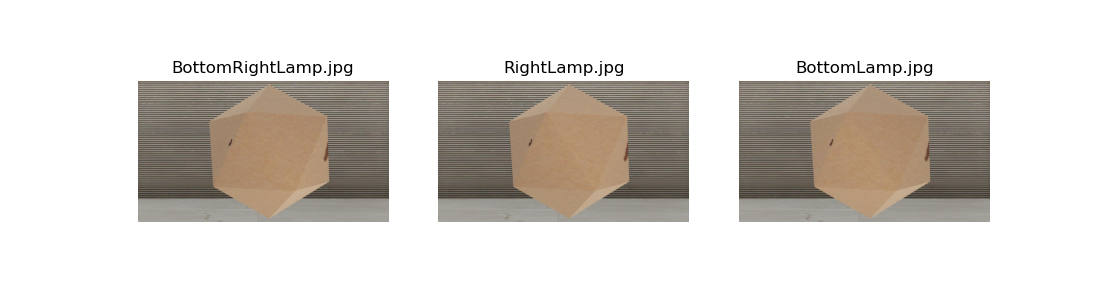

<IPython.core.display.Javascript object>


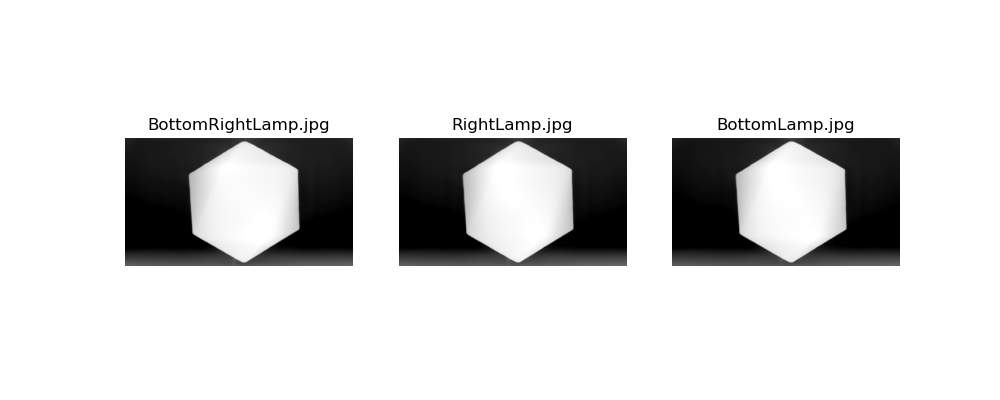

In [3]:
# Depth Maps

img_arr1 = [ "BottomRightLamp.jpg", "RightLamp.jpg", "BottomLamp.jpg"]

# Load Images
imgages1 = list()
images1 = [ load_image(img) for img in img_arr1 ]

# Plot each image
fig, axs = plt.subplots( 1,len(images1), figsize=(11,3) )
for i in range(len(images1)):
    axs[i].imshow( images1[i] )
    axs[i].set_title(img_arr1[i])
    axs[i].axis("off")
    

depths1 = list()

# Compute Depth Maps
depths1 = [ compute_depth(image, "cuda") for image in images1 ]

# Plot each image
fig, axs = plt.subplots( 1,len(depths1), figsize=(10,4) )
for i in range(len(depths1)):
    axs[i].imshow( colorize(depths1[i]) )
    axs[i].set_title(img_arr1[i])
    axs[i].axis("off")

<IPython.core.display.Javascript object>


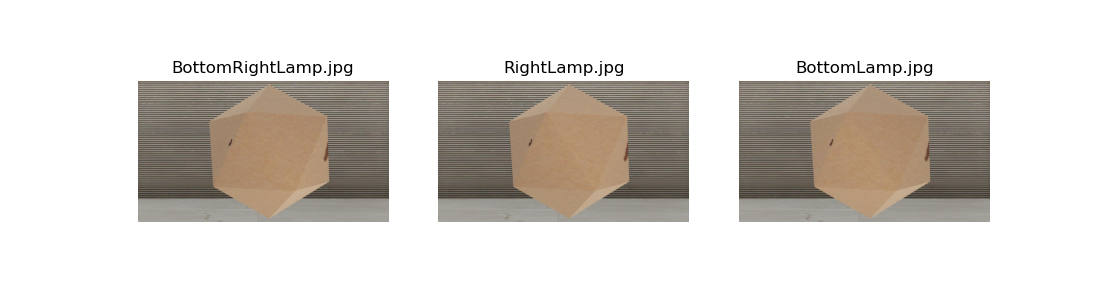

In [4]:
img_arr1 = [ "BottomRightLamp.jpg", "RightLamp.jpg", "BottomLamp.jpg"]

# Load Images
imgages1 = list()
images1 = [ load_image(img) for img in img_arr1 ]

# Plot each image
fig, axs = plt.subplots( 1,len(images1), figsize=(11,3) )
for i in range(len(images1)):
    axs[i].imshow( images1[i] )
    axs[i].set_title(img_arr1[i])
    axs[i].axis("off")
    

<IPython.core.display.Javascript object>


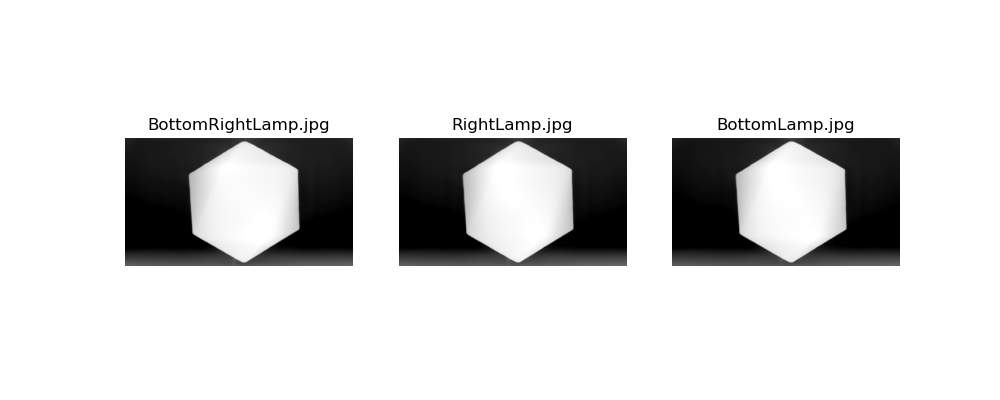

In [31]:
depths1 = list()

# Compute Depth Maps
depths1 = [ compute_depth(image, "cuda") for image in images1 ]

# Plot each depth maps
fig, axs = plt.subplots( 1,len(depths1), figsize=(10,4) )
for i in range(len(depths1)):
    axs[i].imshow( colorize(depths1[i]) )
    axs[i].set_title(img_arr1[i])
    axs[i].axis("off")

##  Low Light:Edge Detection Comparisoon

<IPython.core.display.Javascript object>


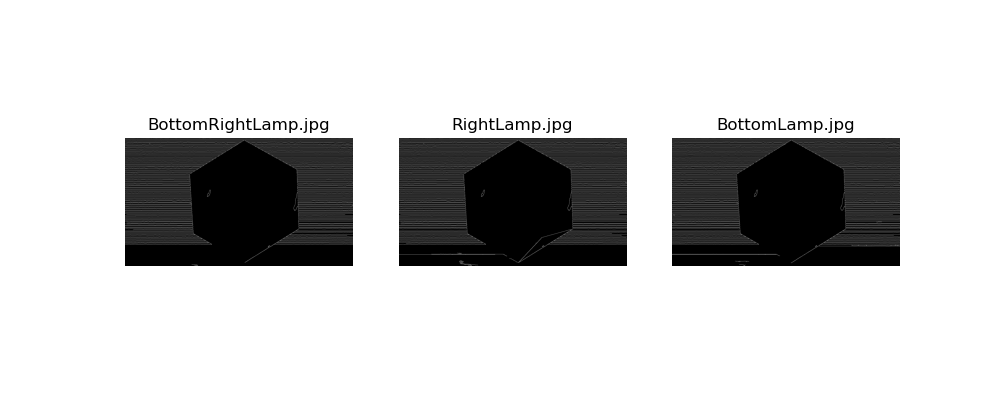

<IPython.core.display.Javascript object>


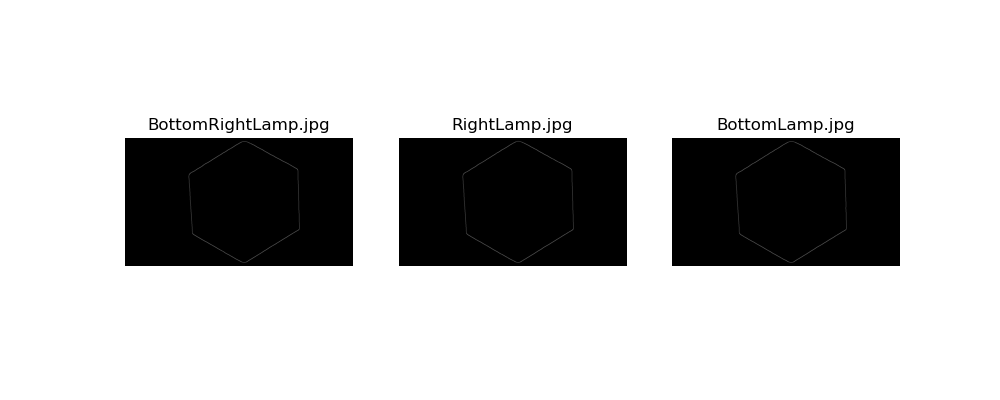

In [5]:
# Function to Compute Edges
def compute_edges(img):

    # Apply Gaussian blur to the image
    blurred = cv2.GaussianBlur(img, (3, 3), 0)
    # Apply the Canny edge detector
    edges = cv2.Canny(blurred, 5, 150)  # Adjust the threshold values as needed

    return edges

# Compute Depth Maps
edges1_col = [ compute_edges(image) for image in images1 ]
edges1_dep = [ compute_edges(colorize(depth)) for depth in depths1 ]

# Plot each edge map from RGB Map
fig, axs = plt.subplots( 1,len(depths1), figsize=(10,4) )
for i in range(len(depths1)):
    axs[i].imshow( edges1_col[i], cmap="gray" )
    axs[i].set_title(img_arr1[i])
    axs[i].axis("off")
    
# Plot each edge map from Depth map
fig, axs = plt.subplots( 1,len(depths1), figsize=(10,4) )
for i in range(len(depths1)):
    axs[i].imshow( edges1_dep[i], cmap="gray" )
    axs[i].set_title(img_arr1[i])
    axs[i].axis("off")

# LowLight: Compute Normals

<IPython.core.display.Javascript object>


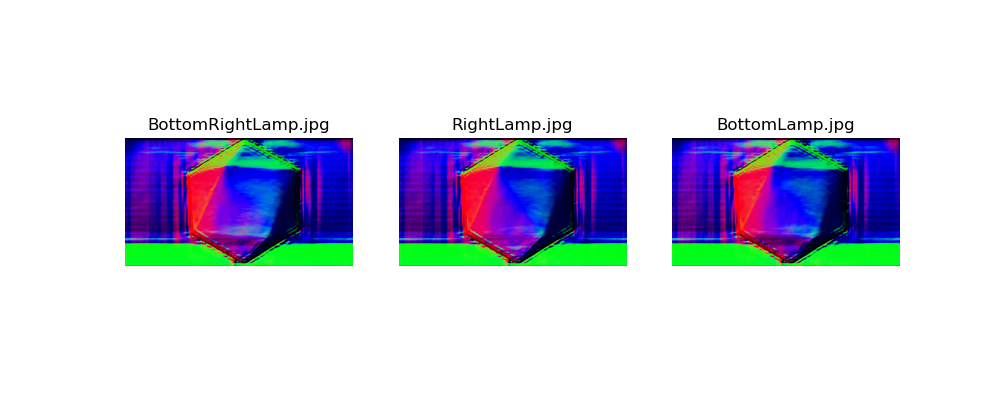

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


In [50]:
def compute_normals(depth_map):
    # Apply Sobel filter
    Z_x = cv2.Sobel(depth_map, -1, 1, 0, ksize=7, scale=1)
    Z_y = cv2.Sobel(depth_map, -1, 0, 1, ksize=7, scale=1)

    # Define tangent vectors
    T_x = np.stack([np.ones_like(Z_x), np.zeros_like(Z_x), Z_x], axis=-1)
    T_y = np.stack([np.zeros_like(Z_y), np.ones_like(Z_y), Z_y], axis=-1)

    # Calculate cross product to get normal vectors
    N = np.cross(T_x, T_y, axisa=-1, axisb=-1)

    # Normalize the normal vectors
    magnitude = np.sqrt(np.sum(N**2, axis=-1, keepdims=True))
    normalized_N = N / magnitude
    
    return normalized_N

normals1 = [ compute_normals(depth) for depth in depths1 ]

# Plot each edge map from RGB Map
fig, axs = plt.subplots( 1,len(depths1), figsize=(10,4) )
for i in range(len(depths1)):
    axs[i].imshow( normals1[i], cmap="gray" )
    axs[i].set_title(img_arr1[i])
    axs[i].axis("off")


## LowLight: Compute Blobs